# Bank Marketing Campaign — XGBoost Modelling

## Setup & Data Loading 

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, accuracy_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
import shap

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

NAVY  = '#1F3864'
BLUE  = '#2E75B6'
TEAL  = '#1ABC9C'
RED   = '#E74C3C'
AMBER = '#F39C12'
GRAY  = '#BDC3C7'

In [16]:
# Load preprocessed data 
TRAIN_URL = "https://raw.githubusercontent.com/kup-kup/telemarketing-prediction/refs/heads/main/processed-data/train.csv"
TEST_URL  = "https://raw.githubusercontent.com/kup-kup/telemarketing-prediction/refs/heads/main/processed-data/test.csv"

df_train = pd.read_csv(TRAIN_URL)
df_test  = pd.read_csv(TEST_URL)

TARGET = 'y'

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET].astype(int)   # True/False → 1/0

X_test  = df_test.drop(columns=[TARGET])
y_test  = df_test[TARGET].astype(int)

FEATURE_NAMES    = X_train.columns.tolist()
X_test = X_test[FEATURE_NAMES]
scale_pos_weight = round(y_train.value_counts()[0] / y_train.value_counts()[1], 2)

# Cross-validation 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train : {X_train.shape[0]:,} rows × {X_train.shape[1]} features')
print(f'Test  : {X_test.shape[0]:,} rows  × {X_test.shape[1]} features')
print(f'Train — No: {(y_train==0).sum():,}  Yes: {y_train.sum():,}')
print(f'Test  — No: {(y_test==0).sum():,}   Yes: {y_test.sum():,}')
print(f'Imbalance ratio   : {scale_pos_weight}:1')
print(f'scale_pos_weight  : {scale_pos_weight}')
print(f'Missing values    : {X_train.isnull().sum().sum()}')

Train : 32,950 rows × 37 features
Test  : 8,238 rows  × 37 features
Train — No: 29,238  Yes: 3,712
Test  — No: 7,310   Yes: 928
Imbalance ratio   : 7.88:1
scale_pos_weight  : 7.88
Missing values    : 0


In [17]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                32950 non-null  float64
 1   education          32950 non-null  float64
 2   campaign           32950 non-null  float64
 3   previous           32950 non-null  float64
 4   cons.conf.idx      32950 non-null  float64
 5   y                  32950 non-null  bool   
 6   marital_married    32950 non-null  bool   
 7   marital_single     32950 non-null  bool   
 8   job_blue-collar    32950 non-null  bool   
 9   job_entrepreneur   32950 non-null  bool   
 10  job_housemaid      32950 non-null  bool   
 11  job_management     32950 non-null  bool   
 12  job_retired        32950 non-null  bool   
 13  job_self-employed  32950 non-null  bool   
 14  job_services       32950 non-null  bool   
 15  job_student        32950 non-null  bool   
 16  job_technician     32950 non-null

## Baseline XGBoost
Train XGBoost with default parameters + `scale_pos_weight` only 

In [20]:
v1_model = XGBClassifier(
    scale_pos_weight  = scale_pos_weight, # 7.88 
    random_state      = 42,
    eval_metric       = 'logloss',
    use_label_encoder = False
)

# CV 5 folds
v1_cv = cross_val_score(v1_model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f'\n5-Fold CV F1 scores:')
for i, s in enumerate(v1_cv, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean : {v1_cv.mean():.4f}')

# train
v1_model.fit(X_train, y_train)

# test
v1_pred       = v1_model.predict(X_test)
v1_pred_proba = v1_model.predict_proba(X_test)[:, 1] # all rows, prob of class 1 (yes)

v1_metrics = {
    'F1 (yes)'   : f1_score(y_test, v1_pred),
    'Recall'     : recall_score(y_test, v1_pred),
    'Precision'  : precision_score(y_test, v1_pred),
    'ROC-AUC'    : roc_auc_score(y_test, v1_pred_proba),
    'Accuracy'   : accuracy_score(y_test, v1_pred),
    'CV F1 Mean' : v1_cv.mean(),
    'CV F1 Std'  : v1_cv.std()
}

print('\nBASELINE RESULTS')
for metric, value in v1_metrics.items():
    print(f'  {metric:<15}: {value:.4f}')

print('\nClassification Report:') #sckit-learn
print(classification_report(y_test, v1_pred, target_names=['no', 'yes']))


5-Fold CV F1 scores:
  Fold 1: 0.4260
  Fold 2: 0.4298
  Fold 3: 0.4344
  Fold 4: 0.4462
  Fold 5: 0.4352
  Mean : 0.4343

BASELINE RESULTS
  F1 (yes)       : 0.4708
  Recall         : 0.6175
  Precision      : 0.3805
  ROC-AUC        : 0.7954
  Accuracy       : 0.8437
  CV F1 Mean     : 0.4343
  CV F1 Std      : 0.0068

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.87      0.91      7310
         yes       0.38      0.62      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.74      0.69      8238
weighted avg       0.88      0.84      0.86      8238



c:\Users\konkanok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:35:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Key Findings:

- Model Stability: The 5-fold Cross-Validation yielded a mean F1-score of 0.4343 with a very low standard deviation (0.0081), indicating that the model's performance is consistent and robust across different data partitions.
- Classification Performance: The model achieved an AUC of 0.7954, demonstrating a strong ability to distinguish between subscribers and non-subscribers.

    - The Recall (0.6175) is relatively high for a baseline, meaning the model successfully captures approximately 62% of potential subscribers.

    - The Precision (0.3805) reflects a trade-off due to the imbalanced data handling; while we capture more "Yes" cases, it comes with a higher rate of false positives.

## (Hyperparameter Tuning) Phase 1: GridSearch on `scale_pos_weight` 


In [21]:
print('PHASE 1: GridSearchCV → scale_pos_weight')
grid_params = {'scale_pos_weight': [1, 2, 3, 4, 5, 7, 7.88, 10]}

grid_search = GridSearchCV(
    estimator = XGBClassifier(
        n_estimators=100, max_depth=5,
        random_state=42, eval_metric='logloss',
        use_label_encoder=False
    ),
    param_grid = grid_params,
    cv         = cv, #5
    scoring    = 'f1',
    verbose    = 1, # show progress
    n_jobs     = -1 # use all CPU cores
)
grid_search.fit(X_train, y_train)

print(f'\nAll values tested:')
print(f'{"Rank":<6} {"scale_pos_weight":<22} {"CV F1 Mean":<14} {"CV F1 Std":<12}')

# Sort results by rank
for _, row in pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score').iterrows():
    spw     = row['params']['scale_pos_weight']
    print(f"  {int(row['rank_test_score']):<5} {spw:<22} "
          f"{row['mean_test_score']:.4f}{'':>8} "
          f"±{row['std_test_score']:.4f}")

print(f'Best CV F1            : {grid_search.best_score_:.4f}')

PHASE 1: GridSearchCV → scale_pos_weight
Fitting 5 folds for each of 8 candidates, totalling 40 fits

All values tested:
Rank   scale_pos_weight       CV F1 Mean     CV F1 Std   
  1     4                      0.4805         ±0.0048
  2     3                      0.4784         ±0.0089
  3     5                      0.4757         ±0.0037
  4     7                      0.4590         ±0.0050
  5     2                      0.4499         ±0.0103
  6     7.88                   0.4451         ±0.0083
  7     10                     0.4103         ±0.0087
  8     1                      0.3690         ±0.0066
Best CV F1            : 0.4805


c:\Users\konkanok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:35:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


the best value was 5 (due to highest CV F1 mean and lower CV F1 Std than 4), outperforming the theoretical ratio of 7.88. This suggests that a slightly lower penalty on minority class misclassification achieves a better balance between Precision and Recall, resulting in a significantly higher CV $F_1$-score of 0.4757 with high stability ($\pm0.0037$)

## (Hyperparameter Tuning) Phase 2: RandomizedSearch on Model Structure

In [22]:
BEST_SPW = 5 # from the best result above
print(f'scale_pos_weight = {BEST_SPW} (from Phase 1)')
print('Testing 80 random combinations')

random_params = {
    'n_estimators'    : [200, 300, 400, 500, 700],
    'max_depth'       : [3, 4, 5, 6, 7],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.08, 0.1], # less LR, more trees
    'min_child_weight': [1, 3, 5, 10], # higher → more conservative (avoid overfitting)
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0], # row sampling for each tree
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0], # col sampling for each tree
    'reg_alpha'       : [0, 0.01, 0.1, 0.5], # remove noise features
    'reg_lambda'      : [1.0, 2.0, 5.0, 10.0], # reduce overfitting (reduce weight)
}

random_search = RandomizedSearchCV(
    estimator = XGBClassifier(
        scale_pos_weight  = BEST_SPW,
        random_state      = 42,
        eval_metric       = 'logloss',
        use_label_encoder = False
    ),
    param_distributions = random_params,
    n_iter       = 80,
    cv           = cv,
    scoring      = 'f1',
    verbose      = 1,
    random_state = 42,
    n_jobs       = -1
)
random_search.fit(X_train, y_train)

BEST_PARAMS = random_search.best_params_
print(f'\nBest params found:')
for k, v in sorted(BEST_PARAMS.items()):
    print(f'   {k:<22}: {v}')
print(f'\nBest CV F1 : {random_search.best_score_:.4f}')
print(f'Baseline CV F1 was: {v1_metrics["CV F1 Mean"]:.4f}')
print(f'Improvement       : +{random_search.best_score_ - v1_metrics["CV F1 Mean"]:.4f}')

# Top 5 combinations
rand_results = pd.DataFrame(random_search.cv_results_)
print(f'\nTop 5 combinations tested:')
print(f'{"Rank":<6} {"CV F1":<10} {"Std":<10} {"n_est":<7} {"depth":<7} {"lr":<7} {"subsample":<11} {"colsample"}')
print('-' * 70)
for _, row in rand_results.sort_values('rank_test_score').head(5).iterrows():
    p = row['params']
    print(f"  {int(row['rank_test_score']):<5} "
          f"{row['mean_test_score']:.4f}{'':>4} "
          f"±{row['std_test_score']:.4f}   "
          f"{p['n_estimators']:<7} {p['max_depth']:<7} "
          f"{p['learning_rate']:<7} {p['subsample']:<11} "
          f"{p['colsample_bytree']}")

scale_pos_weight = 5 (from Phase 1)
Testing 80 random combinations
Fitting 5 folds for each of 80 candidates, totalling 400 fits


c:\Users\konkanok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:37:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best params found:
   colsample_bytree      : 0.6
   learning_rate         : 0.01
   max_depth             : 6
   min_child_weight      : 3
   n_estimators          : 300
   reg_alpha             : 0.01
   reg_lambda            : 5.0
   subsample             : 0.7

Best CV F1 : 0.4978
Baseline CV F1 was: 0.4343
Improvement       : +0.0635

Top 5 combinations tested:
Rank   CV F1      Std        n_est   depth   lr      subsample   colsample
----------------------------------------------------------------------
  1     0.4978     ±0.0071   300     6       0.01    0.7         0.6
  2     0.4977     ±0.0060   300     6       0.01    0.6         0.8
  3     0.4972     ±0.0046   300     7       0.01    0.9         0.8
  4     0.4966     ±0.0054   200     7       0.01    0.6         1.0
  5     0.4960     ±0.0039   200     6       0.03    0.9         1.0


Performance Impact:
- Best CV F1-score: 0.4978
- Improvement: +6.35% over the Baseline model (F1 = 0.4343).
- Stability: The low standard deviation (+-0.0071) confirms that the performance gain is consistent across different data folds.

## Version 2: Tuned XGBoost

Build the final tuned model using best parameters from Phase 1 + Phase 2. 

In [23]:
v2_model = XGBClassifier(
    scale_pos_weight  = BEST_SPW,
    n_estimators      = BEST_PARAMS['n_estimators'],
    max_depth         = BEST_PARAMS['max_depth'],
    learning_rate     = BEST_PARAMS['learning_rate'],
    min_child_weight  = BEST_PARAMS['min_child_weight'],
    subsample         = BEST_PARAMS['subsample'],
    colsample_bytree  = BEST_PARAMS['colsample_bytree'],
    reg_alpha         = BEST_PARAMS['reg_alpha'],
    reg_lambda        = BEST_PARAMS['reg_lambda'],
    random_state      = 42,
    eval_metric       = 'logloss'
)

v2_cv = cross_val_score(
    v2_model, X_train, 
    y_train, 
    cv=cv, 
    scoring='f1', 
    n_jobs=-1)

v2_model.fit(X_train, y_train)

v2_pred       = v2_model.predict(X_test)
v2_pred_proba = v2_model.predict_proba(X_test)[:, 1]

v2_metrics = {
    'F1 (yes)'   : f1_score(y_test, v2_pred),
    'Recall'     : recall_score(y_test, v2_pred),
    'Precision'  : precision_score(y_test, v2_pred),
    'ROC-AUC'    : roc_auc_score(y_test, v2_pred_proba),
    'Accuracy'   : accuracy_score(y_test, v2_pred),
    'CV F1 Mean' : v2_cv.mean(),
    'CV F1 Std'  : v2_cv.std()
}

print('VERSION COMPARISON: Baseline vs Tuned')
print(f'{"Metric":<16} {"V1 Baseline":>12} {"V2 Tuned":>12} {"Change":>10}')
print('-' * 55)

metrics_to_show = [
    'F1 (yes)', 'Recall', 'Precision', 'ROC-AUC', 
    'Accuracy', 'CV F1 Mean', 'CV F1 Std'
]

for metric in metrics_to_show:
    v1 = v1_metrics[metric]
    v2 = v2_metrics[metric]
    diff = v2 - v1
    diff_str = f'+{diff:.4f}' if diff > 0 else f'{diff:.4f}'
    print(f'{metric:<16} {v1:>12.4f} {v2:>12.4f} {diff_str:>10}')

print('\nClassification Report (V2 Tuned):')
print(classification_report(y_test, v2_pred, target_names=['no', 'yes']))

VERSION COMPARISON: Baseline vs Tuned
Metric            V1 Baseline     V2 Tuned     Change
-------------------------------------------------------
F1 (yes)               0.4708       0.5320    +0.0612
Recall                 0.6175       0.6218    +0.0043
Precision              0.3805       0.4649    +0.0845
ROC-AUC                0.7954       0.8171    +0.0217
Accuracy               0.8437       0.8768    +0.0331
CV F1 Mean             0.4343       0.4978    +0.0635
CV F1 Std              0.0068       0.0071    +0.0003

Classification Report (V2 Tuned):
              precision    recall  f1-score   support

          no       0.95      0.91      0.93      7310
         yes       0.46      0.62      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.77      0.73      8238
weighted avg       0.90      0.88      0.88      8238



**Performance Comparison (V1 Baseline vs. V2 Tuned)**
 
- **Precision boost**
  - V1: 0.3805 → V2: 0.4649 
  - +8.73%
  - Business impact: fewer false positives, better marketing efficiency (more real prospects called)

- **Recall maintained**
  - V2 Recall ≈ 0.6218 (≈ 62%)
  - Model keeps capturing the same share of potential subscribers while improving precision

- **Model robustness**
  - CV F1 mean: 0.4978 (+6.35%)
  - CV F1 std: 0.00635 (decreased variability)
  - Interpretation: stronger and more stable generalization across folds

- **Separation power**
  - ROC-AUC: 0.8171 (> 0.80)

## Threshold Optimisation

Default threshold = 0.5. We sweep all thresholds to find two operating points:
- **Option A**: Maximise F1
- **Option B**: Maximise F1 while keeping Recall ≥ 0.70 (business constraint)

In [24]:
xgb_proba = v2_pred_proba
thresholds  = np.arange(0.01, 0.99, 0.01)
f1_list, rec_list, prec_list = [], [], []

for t in thresholds:
    preds = (xgb_proba >= t).astype(int) # convert True/False to 1/0  
    f1_list.append(f1_score(y_test, preds, zero_division=0)) #zero_division=0 to avoid warnings when precision or recall is undefined (base = 0)
    rec_list.append(recall_score(y_test, preds, zero_division=0))
    prec_list.append(precision_score(y_test, preds, zero_division=0))

# Option A: Best F1 
best_f1_idx  = np.argmax(f1_list)
THRESHOLD_A  = thresholds[best_f1_idx]

# Option B: Best F1 with Recall ≥ 0.70 
valid_idx   = [i for i, r in enumerate(rec_list) if r >= 0.70]
best_b_idx  = valid_idx[np.argmax([f1_list[i] for i in valid_idx])]
THRESHOLD_B = thresholds[best_b_idx]

print(f'{"Threshold":<12} {"F1":>8} {"Recall":>8} {"Precision":>10}  Note')
print('-' * 55)

show_thresholds = sorted(set([0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
                               round(THRESHOLD_A, 2), round(THRESHOLD_B, 2)]))
for t in show_thresholds:
    idx  = np.argmin(np.abs(thresholds - t))
    note = ''
    if abs(t - THRESHOLD_A) < 0.011: note = '← Option A: Max F1'
    if abs(t - THRESHOLD_B) < 0.011 and t != THRESHOLD_A: note = '← Option B: Recall≥0.70'
    if abs(t - 0.50) < 0.011: note = '← Default'
    print(f'  {t:<10.2f} {f1_list[idx]:>8.4f} {rec_list[idx]:>8.4f} {prec_list[idx]:>10.4f}  {note}')

print(f'\n{"="*55}')
print('OPERATING POINT RECOMMENDATION')

idx_a = np.argmin(np.abs(thresholds - THRESHOLD_A))
idx_b = np.argmin(np.abs(thresholds - THRESHOLD_B))

print(f'\nOption A — Maximise F1 (threshold = {THRESHOLD_A:.2f}):')
print(f'  F1        : {f1_list[idx_a]:.4f}')
print(f'  Recall    : {rec_list[idx_a]:.4f}')
print(f'  Precision : {prec_list[idx_a]:.4f}')

print(f'\nOption B — Recall ≥ 0.70 (threshold = {THRESHOLD_B:.2f}):')
print(f'  F1        : {f1_list[idx_b]:.4f}')
print(f'  Recall    : {rec_list[idx_b]:.4f} ')
print(f'  Precision : {prec_list[idx_b]:.4f}')

pred_optA = (xgb_proba >= THRESHOLD_A).astype(int)
pred_optB = (xgb_proba >= THRESHOLD_B).astype(int)

Threshold          F1   Recall  Precision  Note
-------------------------------------------------------
  0.20         0.2551   0.9095     0.1483  
  0.25         0.3270   0.8308     0.2035  
  0.30         0.4256   0.7263     0.3010  ← Option B: Recall≥0.70
  0.31         0.4376   0.7080     0.3166  ← Option B: Recall≥0.70
  0.35         0.4635   0.6832     0.3507  
  0.40         0.4937   0.6519     0.3972  
  0.45         0.5220   0.6390     0.4412  
  0.49         0.5330   0.6272     0.4634  ← Default
  0.50         0.5320   0.6218     0.4649  ← Default

OPERATING POINT RECOMMENDATION

Option A — Maximise F1 (threshold = 0.49):
  F1        : 0.5330
  Recall    : 0.6272
  Precision : 0.4634

Option B — Recall ≥ 0.70 (threshold = 0.31):
  F1        : 0.4376
  Recall    : 0.7080 
  Precision : 0.3166


## Export Model

In [25]:
import json

# save model
model_path = "model/xgb_v2_model.json"
v2_model.save_model("model/xgb_v2_model.json")

# save metadata
meta = {
    "threshold_a": float(THRESHOLD_A),
    "threshold_b": float(THRESHOLD_B),
}
meta_path = "model/xgb_v2_meta.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

## XGBoost Performance Chart

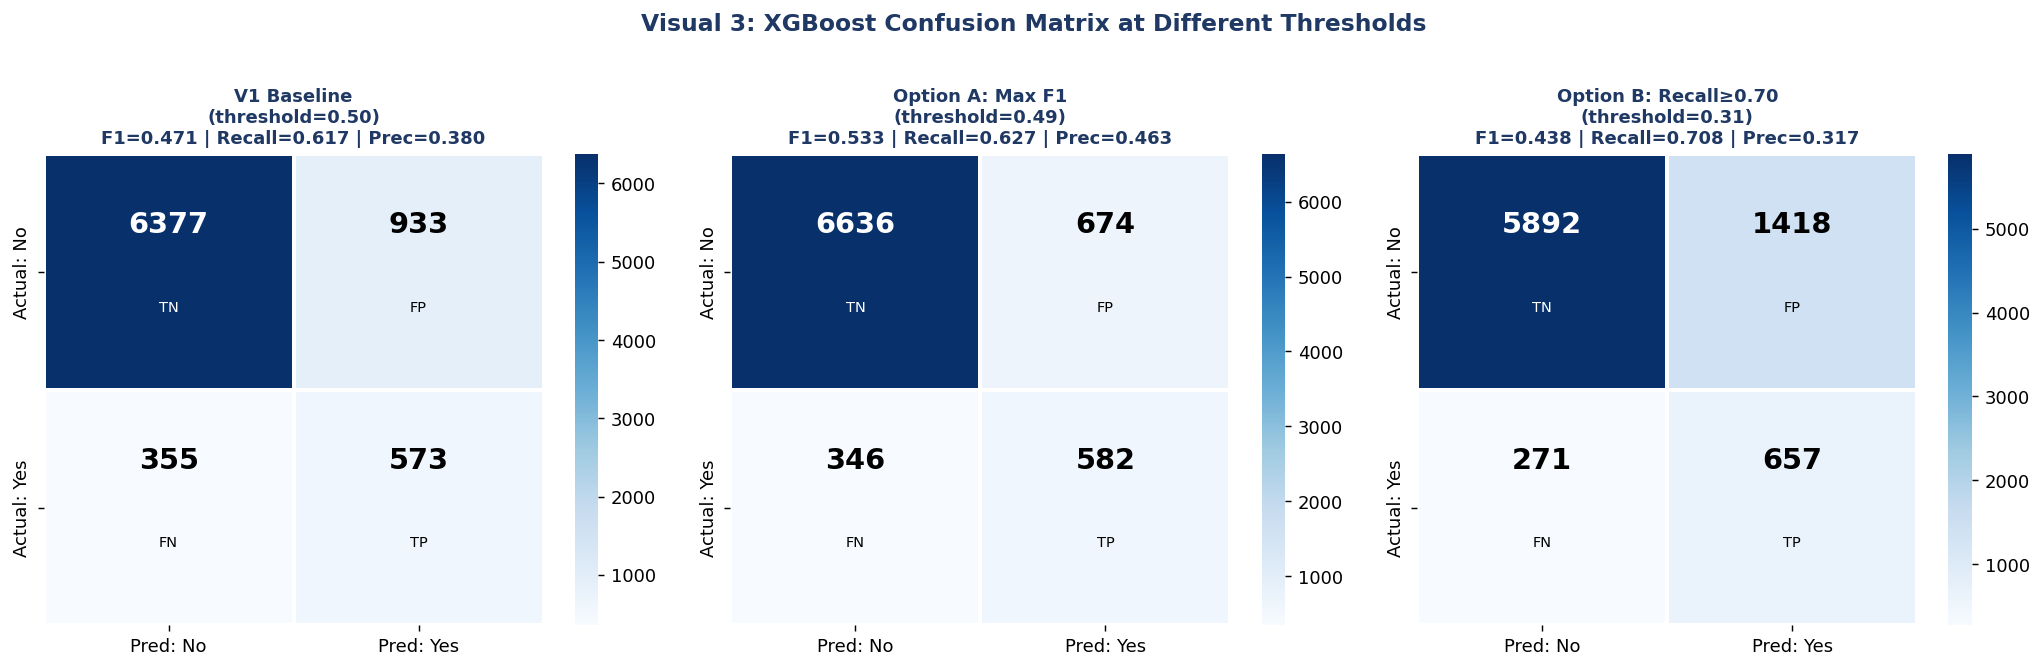

In [26]:
# Confusion Matrices (v1 baseline vs option A vs option B)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Visual 3: XGBoost Confusion Matrix at Different Thresholds',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)

configs = [
    (v1_pred, 'V1 Baseline\n(threshold=0.50)'),
    (pred_optA, f'Option A: Max F1\n(threshold={THRESHOLD_A:.2f})'),
    (pred_optB, f'Option B: Recall≥0.70\n(threshold={THRESHOLD_B:.2f})'),
]

cell_labels = [
    ['TN', 'FP'],
    ['FN', 'TP']
]

for ax, (pred, title) in zip(axes, configs):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=False, ax=ax, cmap='Blues', linewidths=2,
                linecolor='white',
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Actual: No', 'Actual: Yes'])
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            tc  = 'white' if val > cm.max()*0.5 else 'black'
            ax.text(j+0.5, i+0.30, str(val), ha='center', va='center',
                    fontsize=16, fontweight='bold', color=tc)
            ax.text(j+0.5, i+0.65, cell_labels[i][j], ha='center', va='center',
                    fontsize=8, color=tc)
    f1  = f1_score(y_test, pred)
    rec = recall_score(y_test, pred)
    pre = precision_score(y_test, pred)
    ax.set_title(f'{title}\nF1={f1:.3f} | Recall={rec:.3f} | Prec={pre:.3f}',
                 fontsize=10, fontweight='bold', color=NAVY)

plt.tight_layout()
plt.savefig('output/visual_3_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

## SHAP Analysis (Feature Importance)

In [27]:
# Use 500-row sample for speed
np.random.seed(42)
sample_idx    = np.random.choice(len(X_test), size=500, replace=False)
X_test_sample = X_test.iloc[sample_idx]

explainer   = shap.TreeExplainer(v2_model)
shap_values = explainer.shap_values(X_test_sample)

# feature importance 
mean_shap = pd.DataFrame({
    'feature'   : FEATURE_NAMES,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('\nFeatures by SHAP importance (High to Low):')
print(mean_shap.to_string(index=False))


Features by SHAP importance (High to Low):
          feature  importance
       macro_eco1    0.488450
    cons.conf.idx    0.197883
contact_telephone    0.148756
 poutcome_success    0.110456
        month_may    0.093250
              age    0.051926
         campaign    0.039562
  default_unknown    0.032518
  day_of_week_mon    0.023281
         previous    0.019671
        month_oct    0.018298
   marital_single    0.013934
        education    0.013657
  day_of_week_wed    0.013420
      job_retired    0.009364
      housing_yes    0.009125
        month_jun    0.007765
  job_blue-collar    0.007511
  day_of_week_thu    0.007011
         loan_yes    0.004486
        month_mar    0.003956
  day_of_week_tue    0.003389
  marital_married    0.003296
      job_student    0.003231
        month_jul    0.003005
   job_technician    0.002806
        month_nov    0.002795
 job_entrepreneur    0.002624
     job_services    0.002574
   job_management    0.002553
        month_aug    0.002

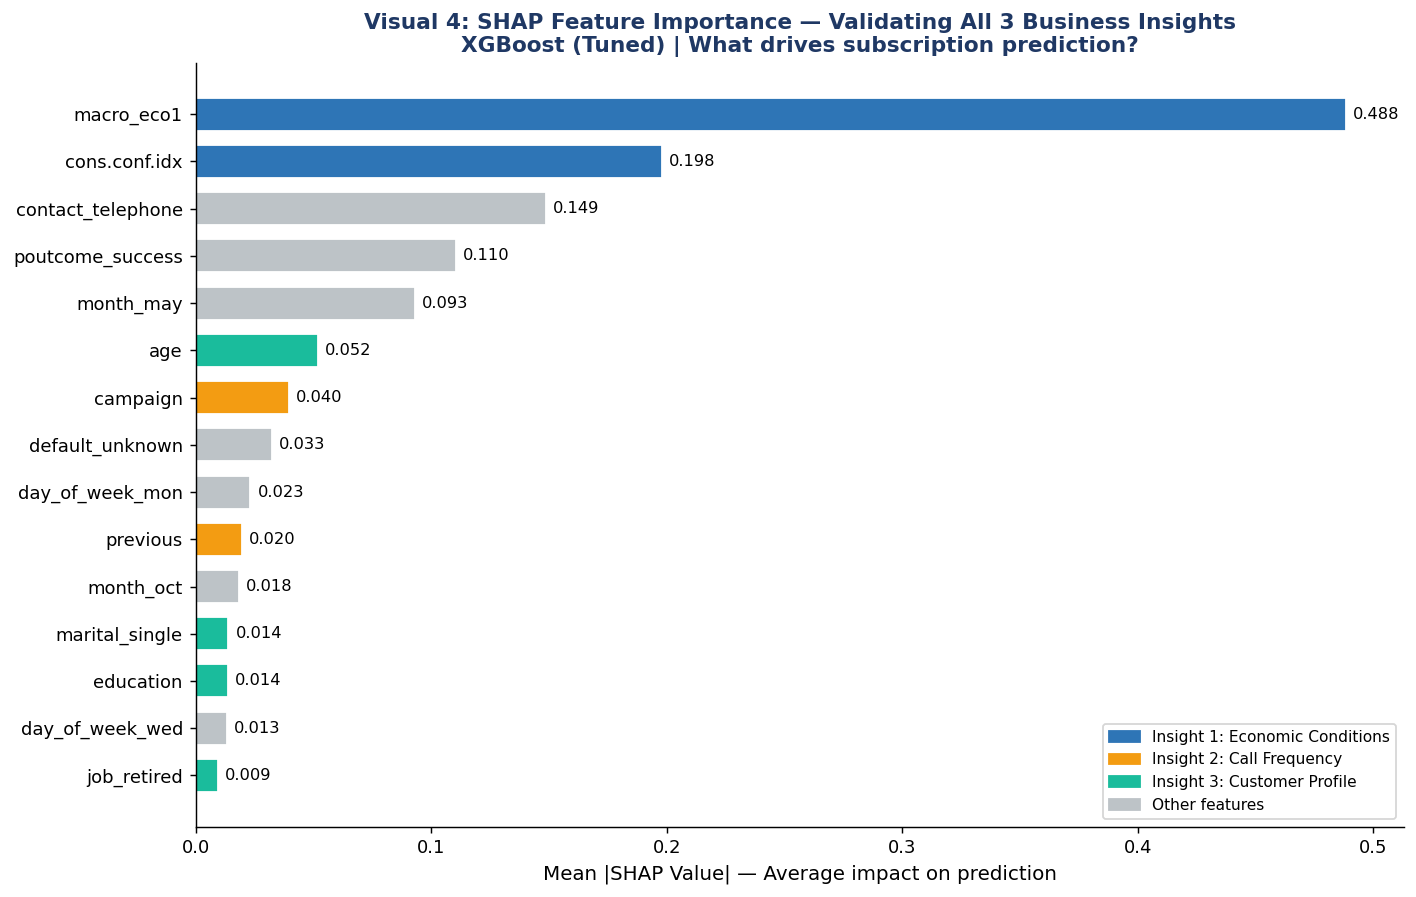

In [28]:
top15 = mean_shap.head(15).copy()

def get_color(feat):
    if any(k in feat for k in ['macro_eco', 'cons.conf', 'euribor', 'emp.var', 'nr.employed']):
        return BLUE
    elif any(k in feat for k in ['campaign', 'pdays', 'previous']):
        return AMBER
    elif any(k in feat for k in ['job', 'age', 'education', 'marital']):
        return TEAL
    return GRAY

colors = [get_color(f) for f in top15['feature']]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top15['feature'][::-1], top15['importance'][::-1],
        color=colors[::-1], edgecolor='white', height=0.7)

for i, (feat, val) in enumerate(zip(top15['feature'][::-1], top15['importance'][::-1])):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color=BLUE,  label='Insight 1: Economic Conditions'),
    mpatches.Patch(color=AMBER, label='Insight 2: Call Frequency'),
    mpatches.Patch(color=TEAL,  label='Insight 3: Customer Profile'),
    mpatches.Patch(color=GRAY,  label='Other features'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8.5)
ax.set_xlabel('Mean |SHAP Value| — Average impact on prediction', fontsize=11)
ax.set_title('Visual 4: SHAP Feature Importance — Validating All 3 Business Insights\n'
             'XGBoost (Tuned) | What drives subscription prediction?',
             fontsize=12, fontweight='bold', color=NAVY)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('output/visual_4_shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

C:\Users\konkanok\AppData\Local\Temp\ipykernel_23440\4149575746.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample,


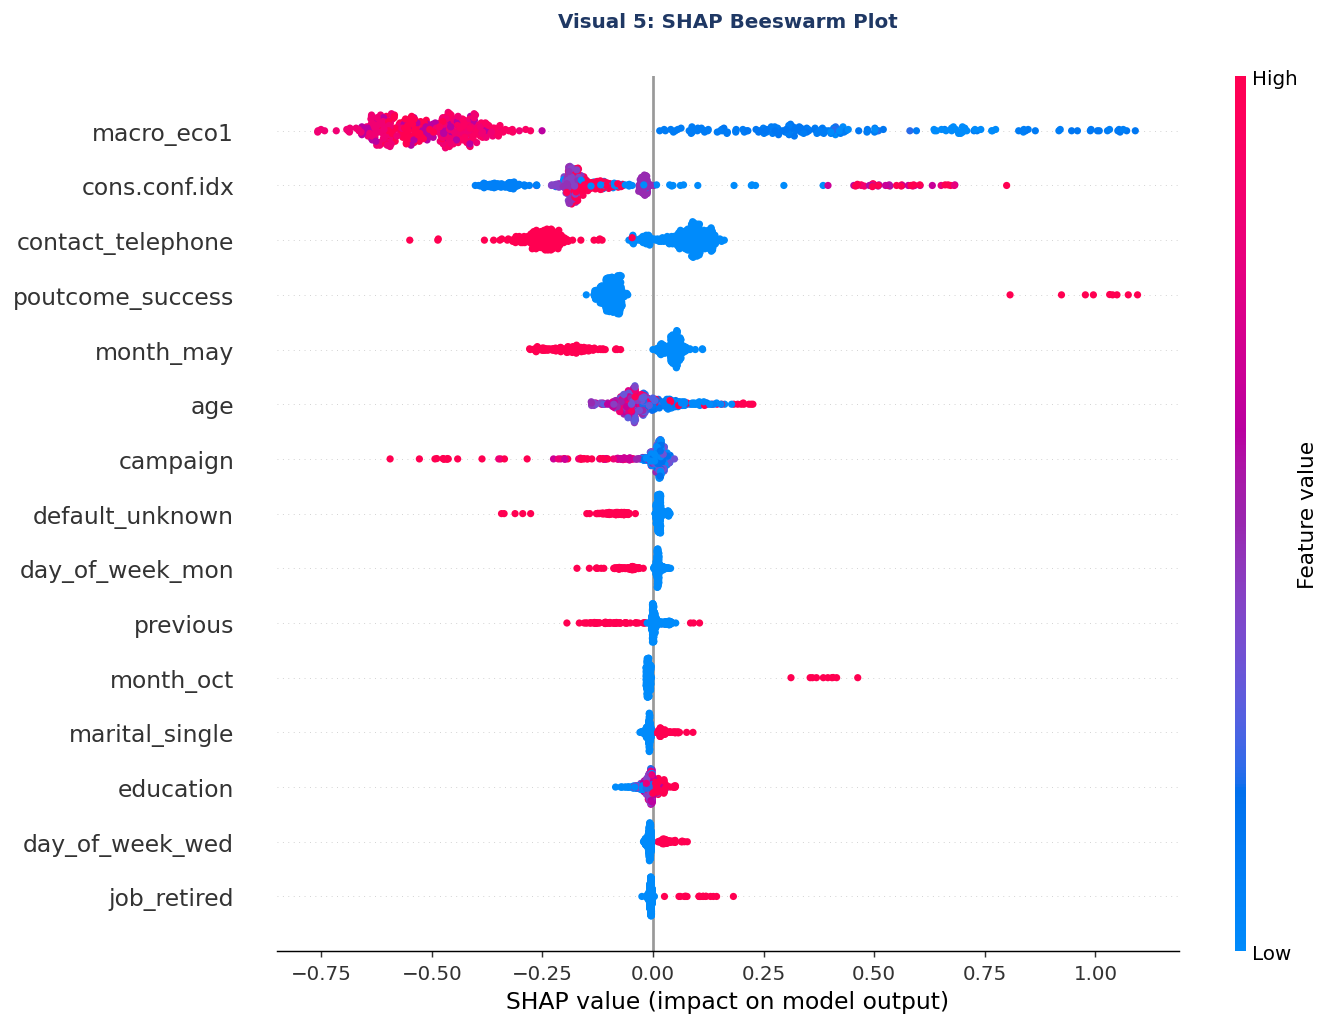

In [29]:
# SHAP Beeswarm

fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(shap_values, X_test_sample,
                  feature_names=FEATURE_NAMES,
                  max_display=15, show=False, plot_size=None)
plt.title('Visual 5: SHAP Beeswarm Plot\n',
          fontsize=11, fontweight='bold', color=NAVY, pad=15)
plt.tight_layout()
plt.savefig('output/visual_5_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

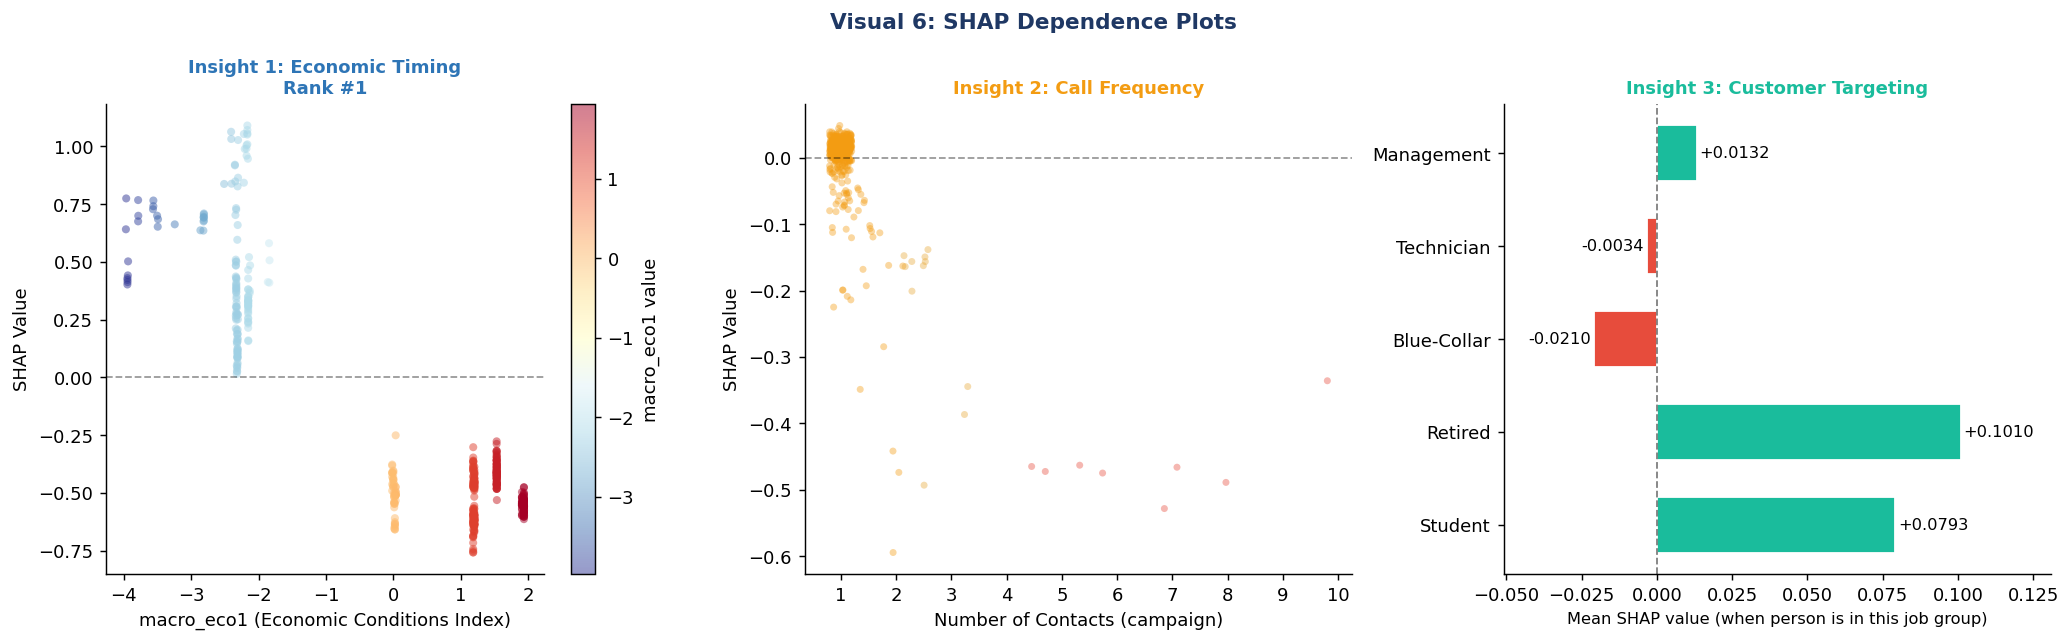

In [30]:
# SHAP Dependence Plots

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Visual 6: SHAP Dependence Plots',
    fontsize=12, fontweight='bold', color=NAVY
)

# Insight 1: macro_eco1
eco_vals = X_test_sample['macro_eco1'].values
eco_shap = shap_values[:, FEATURE_NAMES.index('macro_eco1')]
sc = axes[0].scatter(eco_vals, eco_shap, c=eco_vals,
                     cmap='RdYlBu_r', alpha=0.5, s=20, edgecolors='none')
axes[0].axhline(y=0, color='black', lw=1, linestyle='--', alpha=0.4)
plt.colorbar(sc, ax=axes[0], label='macro_eco1 value')
axes[0].set_xlabel('macro_eco1 (Economic Conditions Index)', fontsize=10)
axes[0].set_ylabel('SHAP Value', fontsize=10)
axes[0].set_title('Insight 1: Economic Timing\nRank #1',
                  fontsize=10, fontweight='bold', color=BLUE)
axes[0].spines[['top', 'right']].set_visible(False)

# Insight 2: campaign
camp_vals = X_test_sample['campaign'].values
camp_shap = shap_values[:, FEATURE_NAMES.index('campaign')]
camp_clip = np.clip(camp_vals, 1, 10)
for c_val in sorted(set(camp_clip)):
    mask = camp_clip == c_val
    color_c = AMBER if c_val <= 2 else RED if c_val >= 4 else '#E8A838'
    axes[1].scatter(
        np.full(mask.sum(), c_val) + np.random.uniform(-0.2, 0.2, mask.sum()),
        camp_shap[mask], alpha=0.4, s=15, color=color_c, edgecolors='none'
    )
axes[1].axhline(y=0, color='black', lw=1, linestyle='--', alpha=0.4)
axes[1].set_xlabel('Number of Contacts (campaign)', fontsize=10)
axes[1].set_ylabel('SHAP Value', fontsize=10)
axes[1].set_title('Insight 2: Call Frequency',
                  fontsize=10, fontweight='bold', color=AMBER)
axes[1].set_xticks(range(1, 11))
axes[1].spines[['top', 'right']].set_visible(False)

# Insight 3: Job segments
job_features = [f for f in ['job_student', 'job_retired', 'job_blue-collar',
                             'job_technician', 'job_management'] if f in FEATURE_NAMES]
job_shap_means, job_labels, job_colors_bar = [], [], []
for feat in job_features:
    idx  = FEATURE_NAMES.index(feat)
    mask = X_test_sample[feat].values == 1
    if mask.sum() > 0:
        mean_s = shap_values[:, idx][mask].mean()
        job_shap_means.append(mean_s)
        job_labels.append(feat.replace('job_', '').title())
        job_colors_bar.append(TEAL if mean_s > 0 else RED)

y_pos = range(len(job_labels))
axes[2].barh(list(y_pos), job_shap_means, color=job_colors_bar,
             edgecolor='white', height=0.6)
axes[2].axvline(x=0, color='black', lw=1, linestyle='--', alpha=0.5)
axes[2].set_yticks(list(y_pos))
axes[2].set_yticklabels(job_labels, fontsize=10)
axes[2].set_xlabel('Mean SHAP value (when person is in this job group)', fontsize=9)
axes[2].set_title('Insight 3: Customer Targeting',
                  fontsize=10, fontweight='bold', color=TEAL)
for val, bar in zip(job_shap_means, axes[2].patches):
    axes[2].text(val + (0.001 if val >= 0 else -0.001),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:+.4f}', va='center', fontsize=9,
                 ha='left' if val >= 0 else 'right')
axes[2].spines[['top', 'right']].set_visible(False)

axes[2].set_xlim(min(job_shap_means) - 0.03, max(job_shap_means) + 0.03)
plt.subplots_adjust(wspace=0.4)

plt.tight_layout()
plt.savefig('output/visual_6_shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()